## Uppal 2025 dual-layer equivalent sources method
In this notebook, we use the method by [Upal, 2025](https://github.com/compgeolab/eqs-gb-norm-of-b) to fit both lower and higher wavelengths.

In [1]:
import pygmt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd

import spherical as sph

Import the real data to create our synthetic.

In [3]:
df = pd.read_csv(
    "../data/blockmedian_alt.csv", sep = '	', 
)

df.columns = ['long', 'lat', 'height']

df2 = pd.read_csv( "../data/blockmedian_mag.csv", sep = '	', 

)

df2.columns = ['long', 'lat', 'mag']

df = pd.merge(df, df2, on=['long', 'lat'])

df

,long,lat,height,mag
0,-52.879747,-14.021349,1833.490,-134.6030
1,-52.936638,-14.029996,1829.980,-139.8650
2,-52.879359,-14.029999,1832.580,-137.8685
3,-52.936532,-14.040001,1830.240,-143.1720
4,-52.879200,-14.040002,1835.830,-141.4190
...,...,...,...,...
152522,-53.635231,-24.409443,1797.515,-59.2815
152523,-53.575943,-24.408768,1788.480,-67.6960
152524,-53.517355,-24.408011,1801.730,-91.0270
152525,-53.872220,-24.416813,1798.740,-41.3835


Reduce the data so we can run faster.

In [4]:
lon = df["long"].values
lat = df["lat"].values
height = df["height"].values


reducer = vd.BlockReduce(reduction=np.median, spacing= 0.06)

coordinates, height_new = reducer.filter(
    (df.long, df.lat), df.height
)
lon, lat = coordinates

coordinates = (lon, lat, height_new)

print(coordinates[0])

[-53.99053165 -53.93143305 -53.87172854 ... -52.87827097 -52.9364585
 -52.87900035]


/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7fa5b82e6840> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7fa5b82e6840> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Ignore the real data anda create our synthetic sources and regional.

In [5]:
inclination, declination = -25, -20  

#Source 1 
source1a, _ = bd.profile_coordinates((-57,-14),(-54,-15.5),size= 1000, non_dimensional_coords= - 30e3)
magnetic_moment1a = hm.magnetic_angles_to_vec(np.full(1000, 7e10), np.full(1000, inclination),np.full(1000, declination))

source1b, _ = bd.profile_coordinates((-57,-16),(-48,-13),size= 1000,non_dimensional_coords=  - 30e3)
magnetic_moment1b = hm.magnetic_angles_to_vec(np.full(1000, 7e10), np.full(1000, inclination),np.full(1000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source1a, source1b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment1a, magnetic_moment1b)]

#Source 2 
source2a, _= bd.profile_coordinates((-52,-16),(-53,-16),size= 300,non_dimensional_coords=  - 25e3)
magnetic_moment2a = hm.magnetic_angles_to_vec(np.full(300, 6e10), np.full(300, inclination),np.full(300, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source2a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment2a)]

source2b, _= bd.profile_coordinates((-54,-16.7),(-53,-16.7), size= 300,non_dimensional_coords= - 22e3)
magnetic_moment2b = hm.magnetic_angles_to_vec(np.full(300, 6e10), np.full(300, inclination),np.full(300, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source2b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment2b)]

#Source 3
source3, _= bd.profile_coordinates((-54,-17.5),(-54.5,-17.5),size= 150,non_dimensional_coords=  - 20e3)
magnetic_moment3 = hm.magnetic_angles_to_vec(np.full(150, 6e10), np.full(150, inclination),np.full(150, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source3)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment3)]

#Source 4
source4a, _= bd.profile_coordinates((-54,-20),(-53.5,-19),size= 250, non_dimensional_coords= - 17e3)
magnetic_moment4a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4a)]

source4b, _= bd.profile_coordinates((-54.5,-19.5),(-54,-18.5),size= 250,non_dimensional_coords=  - 16e3)
magnetic_moment4b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4b)]

source4c, _= bd.profile_coordinates((-54.6,-20.3),(-54.6,-20.4),size= 100,non_dimensional_coords=  - 13e3)
magnetic_moment4c = hm.magnetic_angles_to_vec(np.full(100, 6e10), np.full(100, inclination),np.full(100, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source4c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment4c)]

#Source 5
source5a, _= bd.profile_coordinates((-52,-19),(-49,-19),size= 250,non_dimensional_coords=  - 15e3)
magnetic_moment5a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5a)]

source5b, _= bd.profile_coordinates((-50,-19.6),(-48,-19.6),size= 250,non_dimensional_coords=  - 14e3)
magnetic_moment5b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5b)]

source5c, _= bd.profile_coordinates((-48,-20),(-45,-20),size= 250,non_dimensional_coords= - 15e3)
magnetic_moment5c = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5c)]

source5d, _= bd.profile_coordinates((-45,-20.4),(-48,-20.4),size= 250,non_dimensional_coords=  - 13e3)
magnetic_moment5d = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5d)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5d)]

source5e, _= bd.profile_coordinates((-45,-20.9),(-48,-20.9),size= 250,non_dimensional_coords=  - 12e3)
magnetic_moment5e = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5e)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5e)]

source5f, _= bd.profile_coordinates((-45,-13),(-52,-18.9),size= 500,non_dimensional_coords=  - 11e3)
magnetic_moment5f = hm.magnetic_angles_to_vec(np.full(500, 6e10), np.full(500, inclination),np.full(500, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5f)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5f)]

source5g= vd.scatter_points(region= (-52.3,-52.3,-19.6,-19.6), size= 1, extra_coords=   - 12e3)
magnetic_moment5g = hm.magnetic_angles_to_vec(np.full(1,8e11), np.full(1,45), np.full(1,0))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source5g)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment5g)]

#Source 6
source6a, _= bd.profile_coordinates((-48,-20.9),(-51,-23.9),size= 250,non_dimensional_coords=  - 15e3)
magnetic_moment6a = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6a)]

source6b, _= bd.profile_coordinates((-47,-20.9),(-50,-24.9),size= 250,non_dimensional_coords=  - 14e3)
magnetic_moment6b = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6b)]

source6c, _= bd.profile_coordinates((-51.4,-22),(-50.2,-21),size=250,non_dimensional_coords= - 13e3)
magnetic_moment6c = hm.magnetic_angles_to_vec(np.full(250, 6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source6c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment6c)]

#Source 7
source7a, _= bd.profile_coordinates((-52,-16),(-53.8,-21),size= 250,non_dimensional_coords= - 12e3)
magnetic_moment7a = hm.magnetic_angles_to_vec(np.full(250, -6e10), np.full(250, inclination),np.full(250, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source7a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment7a)]

#Source 8 
source8a, _= bd.profile_coordinates((-57,-26.5),(-54,-23.1),size= 400,non_dimensional_coords=  - 15e3)
magnetic_moment8a = hm.magnetic_angles_to_vec(np.full(400, -9e10), np.full(400, inclination),np.full(400, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source8a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment8a)]


#Source 9
source9a, _= bd.profile_coordinates((-48,-26.5),(-54,-22),size= 5000,non_dimensional_coords=  - 6e3)
magnetic_moment9a = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9a)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9a)]

source9b, _= bd.profile_coordinates((-46.5,-26.4),(-51.5,-22.2),size= 5000, non_dimensional_coords= - 3e3)
magnetic_moment9b = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9b)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9b)]

source9c, _= bd.profile_coordinates((-48,-26.6),(-51,-22.5),size= 5000,non_dimensional_coords=  - 5e3)
magnetic_moment9c = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9c)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9c)]

source9d, _= bd.profile_coordinates((-51.4,-19),(-45,-26.5),size= 5000,non_dimensional_coords=  - 4e3)
magnetic_moment9d = hm.magnetic_angles_to_vec(np.full(5000, -6e8), np.full(5000, inclination),np.full(5000, declination))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, source9d)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment9d)]

#Regional Field
regional= vd.scatter_points(region=(-55,-50,-23,-17), size=90, extra_coords=-60e3, random_state=1)
magnetic_moment_reg = hm.magnetic_angles_to_vec(np.full(90, -9e12), np.full(90, -90),np.full(90, 45))
source_coordinates = [np.concatenate([s,o]) for s,o in zip(source_coordinates, regional)]
magnetic_moment = [np.concatenate([s,o]) for s,o in zip(magnetic_moment, magnetic_moment_reg)]

In [7]:
magnetic_field = sph.dipole_magnetic_geodetic(coordinates, source_coordinates, magnetic_moment)
magnetic_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

#Random noise

noise_level =  0.01 * vd.maxabs(magnetic_anomaly)

magnetic_anomaly += np.random.default_rng(42).normal(
    0, noise_level, size=magnetic_anomaly.shape
)

(np.float64(-57.0669865475),
 np.float64(-46.3529934225),
 np.float64(-24.9070073855),
 np.float64(-13.5329973645))

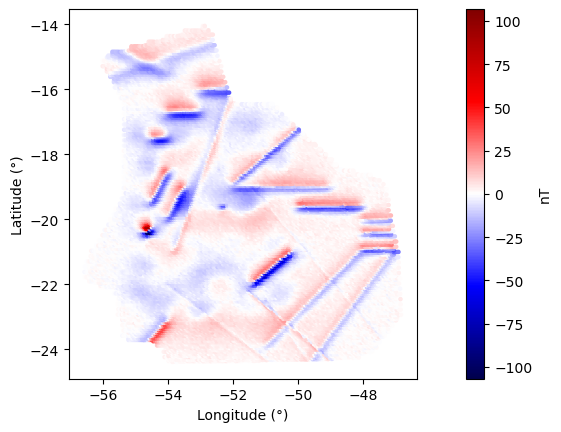

In [8]:
scale = vd.maxabs(magnetic_anomaly)
plt.scatter(coordinates[0], coordinates[1],  c = magnetic_anomaly, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

Use our function to create a grid of true total field anomaly.

In [9]:
grid_coord = vd.grid_coordinates((-57, -46, -26, -13), shape=(150, 150), extra_coords= 500)

magnetic_field = sph.dipole_magnetic_geodetic(grid_coord, source_coordinates, magnetic_moment)
grided_dd_anomaly = hm.total_field_anomaly(magnetic_field, inclination, declination)

# Deep equivalent sources
Use a block reduce method to create our deep equivalent sources.

In [10]:
reducer = vd.BlockReduce(reduction=np.mean, spacing=0.3,  center_coordinates=False, drop_coords=False)
deep_equivalent_sources, magnetic_anomaly_reduced = reducer.filter(coordinates, magnetic_anomaly)

/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function mean at 0x7fa5d40f6020> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.13/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function mean at 0x7fa5d40f6020> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


Plot the data so we can visualize the reduced version.

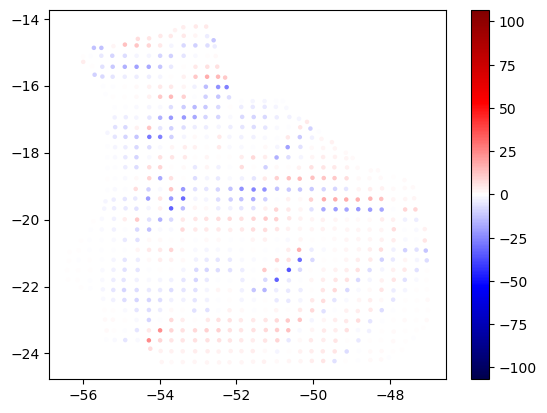

In [11]:
plt.scatter(*deep_equivalent_sources[:2], c = magnetic_anomaly_reduced,s = 5, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar()

Run the inversion of the deep equivalent sources.

In [12]:
%%time
eqs_deep = sph.EquivalentSourcesMagGeod(damping=1e-10, depth=80e3)
eqs_deep.fit(deep_equivalent_sources, inclination, declination, magnetic_anomaly_reduced)


CPU times: user 965 ms, sys: 55.6 ms, total: 1.02 s
Wall time: 696 ms


Predict the deep equivalent sources and calculate the residuals.

In [13]:
predicted_deep =  hm.total_field_anomaly(eqs_deep.predict(coordinates), inclination, declination)
residuals_deep = magnetic_anomaly - predicted_deep 

Plot the predidted and the residuals of the deep layer, to check if the EQS is good.

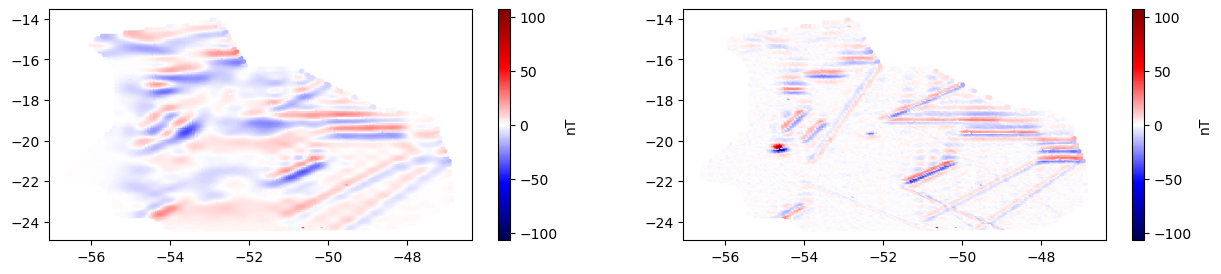

In [14]:
scale_deep = vd.maxabs(predicted_deep)
plt.figure(figsize=(15,3))


plt.subplot(1,2,1)
plt.scatter(coordinates[0], coordinates[1],c = predicted_deep, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(1,2,2)
plt.scatter(coordinates[0], coordinates[1],c = residuals_deep, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

# Shallow equivalent sources
Use the gradient-boosted method to generate our shallow equivalent sources.

In [15]:
%%time
eqs_shallow = sph.EquivalentSourcesMagGeodGB(damping=1e3, depth=10e3, window_size=200e3)
eqs_shallow.fit(coordinates, inclination, declination, residuals_deep)
print(eqs_shallow.window_size_)

Output()

200000.0
CPU times: user 5min 51s, sys: 2.55 s, total: 5min 53s
Wall time: 1min 9s


Plot the predidted and the residuals of the shallow layer, to check if the eqs is good.

In [16]:
predicted_shallow =  hm.total_field_anomaly(eqs_shallow.predict(coordinates), inclination, declination)
residuals_shallow = residuals_deep - predicted_shallow 

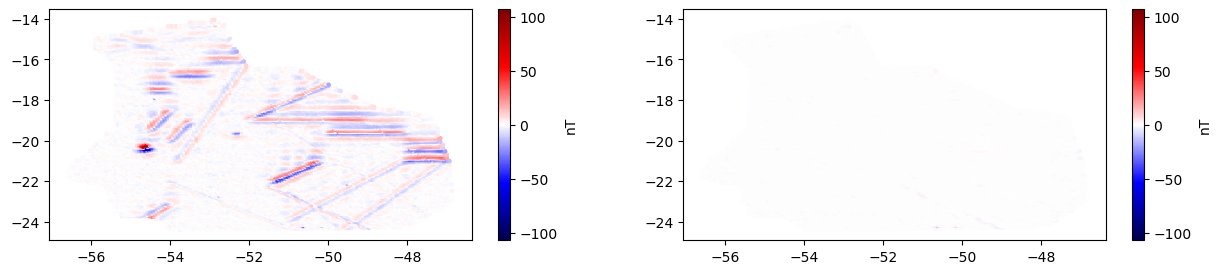

In [17]:
scale_deep = vd.maxabs(predicted_shallow)
plt.figure(figsize=(15,3))


plt.subplot(1,2,1)
plt.scatter(coordinates[0], coordinates[1],c = predicted_shallow, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

plt.subplot(1,2,2)
plt.scatter(coordinates[0], coordinates[1],c = residuals_shallow, s = 5,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')

Predict both on a regular grid and sum.

In [18]:
total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coord,
    hm.total_field_anomaly(eqs_deep.predict(grid_coord), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid


total_field_anomaly_predicted += vd.make_xarray_grid(
    grid_coord,
    hm.total_field_anomaly(eqs_shallow.predict(grid_coord), inclination, declination),
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

Plot the total field anomaly predicted, the true total field anomaly and the difference.

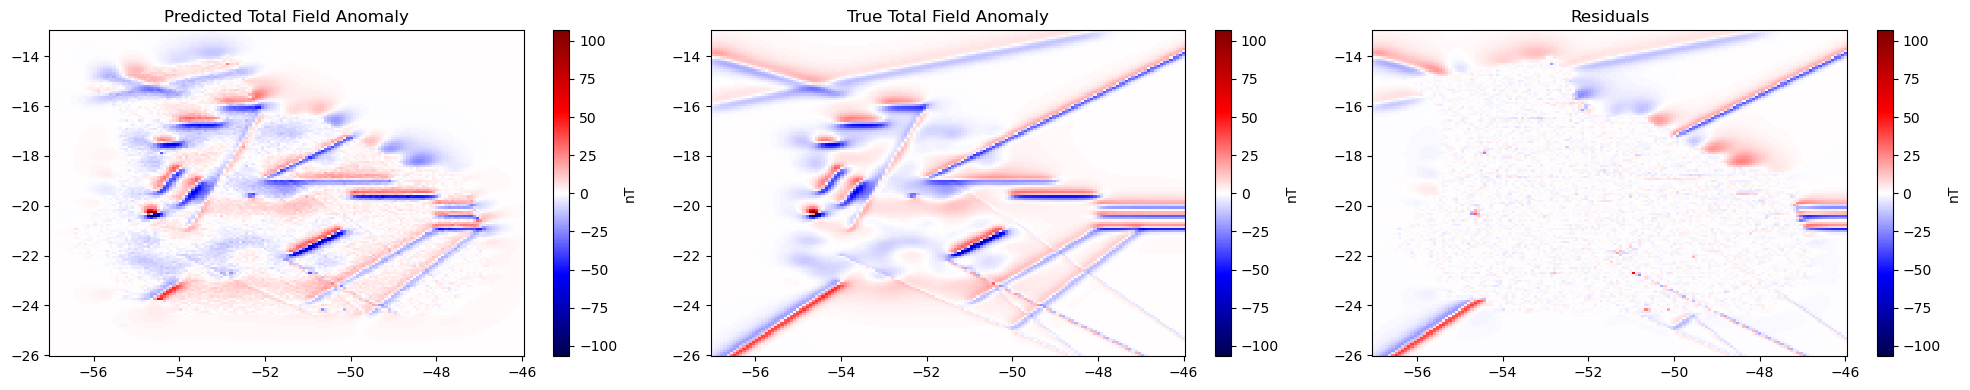

In [19]:
diff_grid_tfa = grided_dd_anomaly -  total_field_anomaly_predicted

plt.figure(figsize=(20,4))

plt.subplot(1,3,1)
plt.title("Predicted Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], total_field_anomaly_predicted, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')


plt.subplot(1,3,2)
plt.title("True Total Field Anomaly")
plt.pcolormesh(
    *grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale
)
plt.colorbar(label='nT')


plt.subplot(1,3,3)
plt.title('Residuals')
plt.pcolormesh(
    *grid_coord[:2], diff_grid_tfa, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.tight_layout()

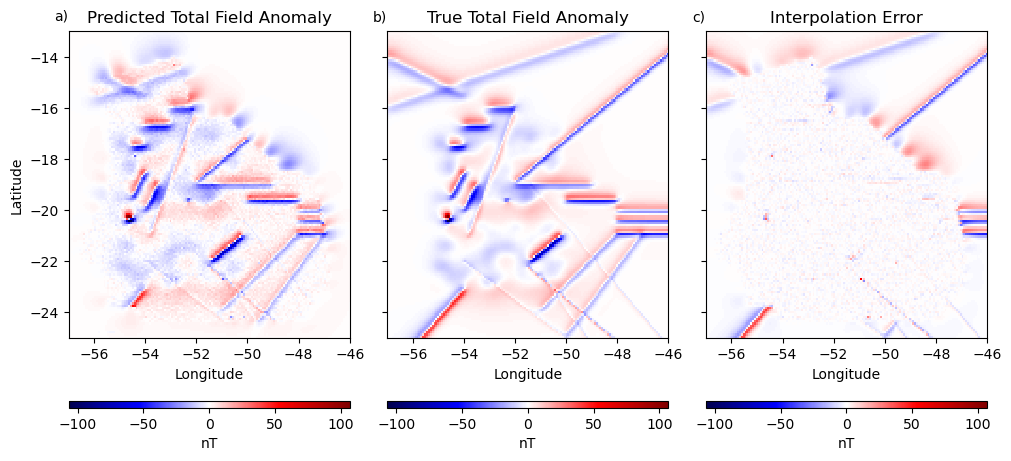

In [20]:
region = [-57, -46, -25, -13]
fig, axes = plt.subplots(1, 3, figsize=(10, 4.5), sharey=True, layout="constrained")  


im0 = axes[0].pcolormesh(*grid_coord[:2], total_field_anomaly_predicted, cmap="seismic", vmin=-scale, vmax=scale)
axes[0].set_title("Predicted Total Field Anomaly")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

im1 = axes[1].pcolormesh(*grid_coord[:2], grided_dd_anomaly, cmap="seismic", vmin=-scale, vmax=scale)
axes[1].set_title("True Total Field Anomaly")
axes[1].set_aspect("equal")


diff_grid_tfa = grided_dd_anomaly - total_field_anomaly_predicted
im2 = axes[2].pcolormesh(*grid_coord[:2], diff_grid_tfa, cmap="seismic", vmin=-scale, vmax=scale)
axes[2].set_title(f"Interpolation Error")
axes[2].set_aspect("equal")


cb0 = fig.colorbar(im0, ax=axes[0], orientation="horizontal", aspect=40)
cb0.set_label("nT")
cb1 = fig.colorbar(im1, ax=axes[1], orientation="horizontal", aspect=40)
cb1.set_label("nT")
cb2 = fig.colorbar(im2, ax=axes[2], orientation="horizontal", aspect=40)
cb2.set_label("nT")

for ax in axes.ravel():
    ax.set_xlim(*region[:2])
    ax.set_ylim(*region[2:])
    ax.set_xlabel("Longitude")

for ax, label in zip(axes, "abc"):
    ax.text(-0.05, 1.035, f"{label})", transform=ax.transAxes)

# plt.savefig("total_field_anomaly_inversion-gb.png", dpi=200, format='png')
plt.show()
